# Caption-Sentiment Vergleich

Dieses Notebook wertet die zuvor berechneten Caption-Sentiment-Ergebnisse aus.


In [6]:
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = "DejaVu Sans"


COLOR_VI = "#2A9D8F"
COLOR_RI = "#B85C7A"
COLOR_INK = "#24323A"
COLOR_MUTED = "#667085"
COLOR_GRID = "#E6E8EC"
COLOR_PANEL = "#F7F8FA"
COLOR_ZERO = "#8F98A3"
COLOR_AI = COLOR_VI
COLOR_REAL = COLOR_RI
PALETTE = {"VI": COLOR_VI, "RI": COLOR_RI}
TYPE_LABELS = {"KI": "VI", "Real": "RI", "VI": "VI", "RI": "RI", "AI": "VI", "REAL": "RI"}
TYPE_NOTE = "VI = virtuelle Influencerinnen; RI = reale Influencerinnen"


def style_axis(ax, x_grid=False):
    ax.grid(True, axis="y", color=COLOR_GRID, linewidth=0.9)
    if x_grid:
        ax.grid(True, axis="x", color=COLOR_GRID, linewidth=0.8)
    else:
        ax.grid(False, axis="x")
    ax.tick_params(colors=COLOR_INK, labelsize=12)
    ax.xaxis.label.set_color(COLOR_INK)
    ax.yaxis.label.set_color(COLOR_INK)
    ax.title.set_color(COLOR_INK)
    sns.despine(ax=ax)


def add_caption(fig, text, y=0.012):
    fig.text(0.01, y, text, ha="left", va="bottom", fontsize=9.2, color=COLOR_MUTED)


def cohens_d(group_a, group_b):
    a = pd.Series(group_a).dropna().to_numpy()
    b = pd.Series(group_b).dropna().to_numpy()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    return (a.mean() - b.mean()) / sqrt(pooled_var) if pooled_var > 0 else np.nan


def p_text(p_value):
    return "signifikant" if pd.notna(p_value) and p_value < 0.05 else "nicht signifikant"


def d_interpretation(d_value):
    abs_d = abs(d_value)
    if abs_d < 0.2:
        return "vernachlässigbar klein"
    if abs_d < 0.5:
        return "klein"
    if abs_d < 0.8:
        return "mittel"
    return "groß"


def rho_interpretation(rho_value):
    abs_rho = abs(rho_value)
    if abs_rho < 0.1:
        return "praktisch kein Zusammenhang"
    if abs_rho < 0.3:
        return "schwacher Zusammenhang"
    if abs_rho < 0.5:
        return "mittlerer Zusammenhang"
    return "starker Zusammenhang"




In [2]:
BASE_DIR = Path.cwd().resolve().parents[1]
RESULTS_CSV = BASE_DIR / "comments" / "results" / "01_caption_sentiment_results.csv"
print(RESULTS_CSV)


/Users/hannahernstberger/Documents/Master_/comments/results/01_caption_sentiment_results.csv


In [7]:
df = pd.read_csv(RESULTS_CSV)

fallback_columns = {
    "sentiment_index": "caption_sentiment_index",
    "negative": "caption_sentiment_negative",
    "neutral": "caption_sentiment_neutral",
    "positive": "caption_sentiment_positive",
}
for target, fallback in fallback_columns.items():
    if target not in df.columns:
        if fallback not in df.columns:
            raise ValueError(f"Spalte fehlt: {target} oder {fallback}")
        df[target] = df[fallback]

if "sentiment_label_de" not in df.columns:
    if "caption_sentiment_label" in df.columns:
        label_source = df["caption_sentiment_label"]
    elif "sentiment_label" in df.columns:
        label_source = df["sentiment_label"]
    else:
        raise ValueError("Spalte fehlt: sentiment_label_de, caption_sentiment_label oder sentiment_label")
    df["sentiment_label_de"] = label_source.map({"negative": "Negativ", "neutral": "Neutral", "positive": "Positiv"})

df["Typ_plot"] = df["Typ"].map(TYPE_LABELS).fillna(df["Typ"])

group_summary = (
    df.groupby("Typ")
    .agg(
        n=("video_id", "count"),
        sentiment_index_M=("sentiment_index", "mean"),
        sentiment_index_SD=("sentiment_index", "std"),
        sentiment_index_Md=("sentiment_index", "median"),
        positive_M=("positive", "mean"),
        neutral_M=("neutral", "mean"),
        negative_M=("negative", "mean"),
    )
    .round(4)
    .reset_index()
)
group_summary_display = group_summary.copy()
group_summary_display["Typ"] = group_summary_display["Typ"].map(TYPE_LABELS).fillna(group_summary_display["Typ"])

ki = df.loc[df["Typ"] == "KI", "sentiment_index"]
real = df.loc[df["Typ"] == "Real", "sentiment_index"]
u_stat, u_p = mannwhitneyu(ki, real, alternative="two-sided")
d_value = cohens_d(ki, real)
rho_all, p_all = spearmanr(df["sentiment_index"], df["video_engagement_rate"], nan_policy="omit")
rho_ki, p_ki = spearmanr(
    df.loc[df["Typ"] == "KI", "sentiment_index"],
    df.loc[df["Typ"] == "KI", "video_engagement_rate"],
    nan_policy="omit",
)
rho_real, p_real = spearmanr(
    df.loc[df["Typ"] == "Real", "sentiment_index"],
    df.loc[df["Typ"] == "Real", "video_engagement_rate"],
    nan_policy="omit",
)
label_share_df = df.groupby(["Typ_plot", "sentiment_label_de"]).size().rename("Anzahl").reset_index()
label_share_df["Anteil_prozent"] = label_share_df.groupby("Typ_plot")["Anzahl"].transform(lambda s: 100 * s / s.sum())
ct = pd.crosstab(df["Typ"], df["sentiment_label_de"])
chi2, chi2_p, chi2_df, _ = chi2_contingency(ct)
display(group_summary_display)



,Typ,n,sentiment_index_M,sentiment_index_SD,sentiment_index_Md,positive_M,neutral_M,negative_M
0,VI,301,0.4328,0.5038,0.5522,0.5367,0.3593,0.1039
1,RI,728,0.3699,0.5846,0.5143,0.5173,0.3353,0.1474


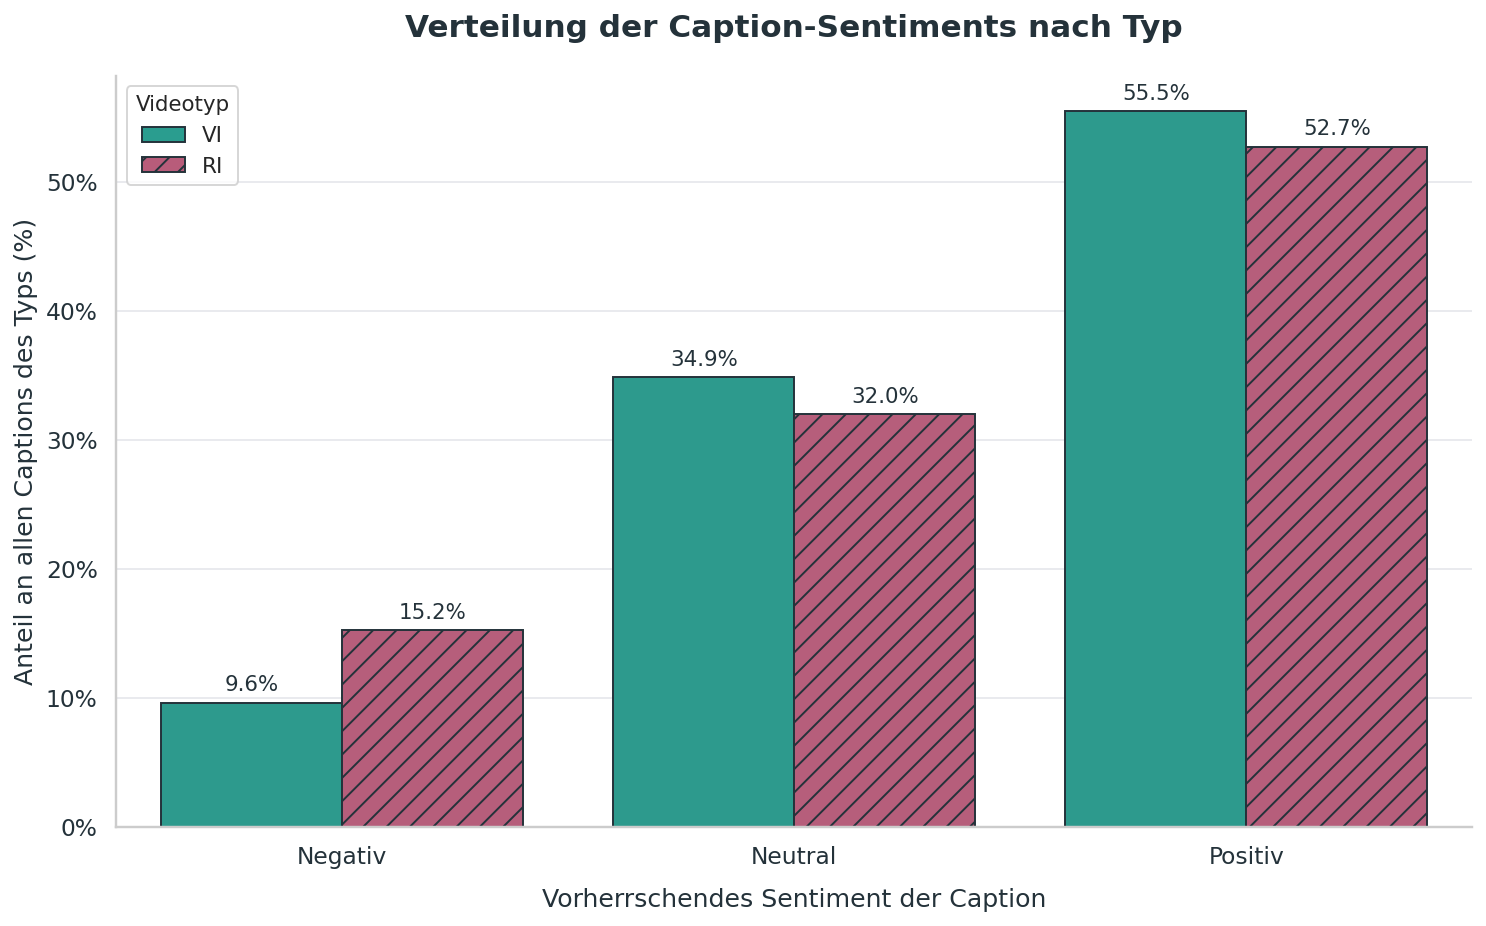

In [8]:
plot_df = label_share_df.copy()
plot_df["sentiment_label_de"] = pd.Categorical(
    plot_df["sentiment_label_de"], categories=["Negativ", "Neutral", "Positiv"], ordered=True
)
plot_df = plot_df.sort_values(["sentiment_label_de", "Typ_plot"])

fig, ax1 = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
sns.barplot(
    data=plot_df,
    x="sentiment_label_de",
    y="Anteil_prozent",
    hue="Typ_plot",
    hue_order=["VI", "RI"],
    palette=PALETTE,
    saturation=0.95,
    edgecolor=COLOR_INK,
    linewidth=1.0,
    ax=ax1,
)
for container, hatch in zip(ax1.containers, ["", "//"]):
    for bar in container:
        bar.set_hatch(hatch)
    ax1.bar_label(container, fmt="%.1f%%", padding=4, fontsize=11, color=COLOR_INK)
ax1.set_title("Verteilung der Caption-Sentiments nach Typ", fontsize=16, fontweight="semibold", pad=20)
ax1.set_xlabel("Vorherrschendes Sentiment der Caption", fontsize=13, labelpad=10)
ax1.set_ylabel("Anteil an allen Captions des Typs (%)", fontsize=13)
ax1.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax1.tick_params(axis="both", labelsize=12)
bar_legend = [
    Patch(facecolor=COLOR_VI, edgecolor=COLOR_INK, label="VI"),
    Patch(facecolor=COLOR_RI, edgecolor=COLOR_INK, hatch="//", label="RI"),
]
ax1.legend(handles=bar_legend, title="Videotyp", frameon=True, fontsize=11, title_fontsize=11)
style_axis(ax1)
plt.show()




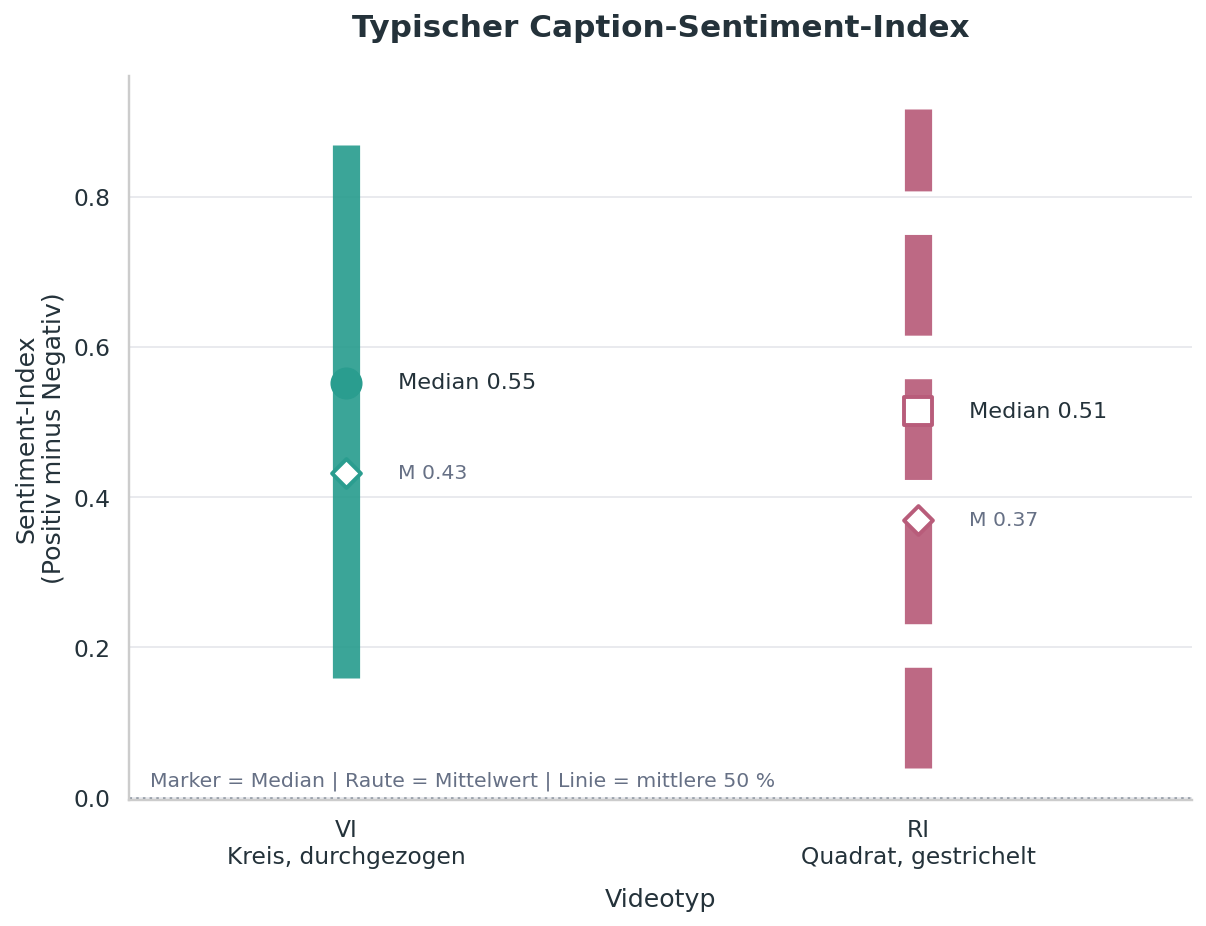

In [5]:
summary_plot_df = (
    df.groupby("Typ_plot")["sentiment_index"]
    .agg(Q1=lambda s: s.quantile(0.25), Median="median", Q3=lambda s: s.quantile(0.75), Mittelwert="mean")
    .reindex(["VI", "RI"])
    .reset_index()
)

fig, ax2 = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
for x, row in enumerate(summary_plot_df.to_dict("records")):
    typ = row["Typ_plot"]
    color = PALETTE[typ]
    linestyle = "-" if typ == "VI" else "--"
    marker = "o" if typ == "VI" else "s"
    ax2.vlines(x, row["Q1"], row["Q3"], color=color, linewidth=14, alpha=0.92, linestyles=linestyle)
    ax2.scatter(x, row["Median"], color=color if typ == "VI" else "white", edgecolor=color, linewidth=2, marker=marker, s=210, zorder=4)
    ax2.scatter(x, row["Mittelwert"], color="white", edgecolor=color, linewidth=2, marker="D", s=110, zorder=5)
    ax2.text(x + 0.09, row["Median"], f"Median {row['Median']:.2f}", va="center", fontsize=11.5, color=COLOR_INK)
    ax2.text(x + 0.09, row["Mittelwert"], f"M {row['Mittelwert']:.2f}", va="center", fontsize=10.5, color=COLOR_MUTED)

ax2.axhline(0, color=COLOR_ZERO, linestyle=":", linewidth=1.3)
ax2.set_xticks([0, 1], ["VI\nKreis, durchgezogen", "RI\nQuadrat, gestrichelt"])
ax2.set_xlim(-0.38, 1.48)
ax2.set_title("Typischer Caption-Sentiment-Index", fontsize=16, fontweight="semibold", pad=20)
ax2.set_xlabel("Videotyp", fontsize=13, labelpad=10)
ax2.set_ylabel("Sentiment-Index\n(Positiv minus Negativ)", fontsize=13)
ax2.tick_params(axis="both", labelsize=12)
ax2.text(0.02, 0.02, "Marker = Median | Raute = Mittelwert | Linie = mittlere 50 %", transform=ax2.transAxes, fontsize=10.5, color=COLOR_MUTED)
style_axis(ax2)
plt.show()


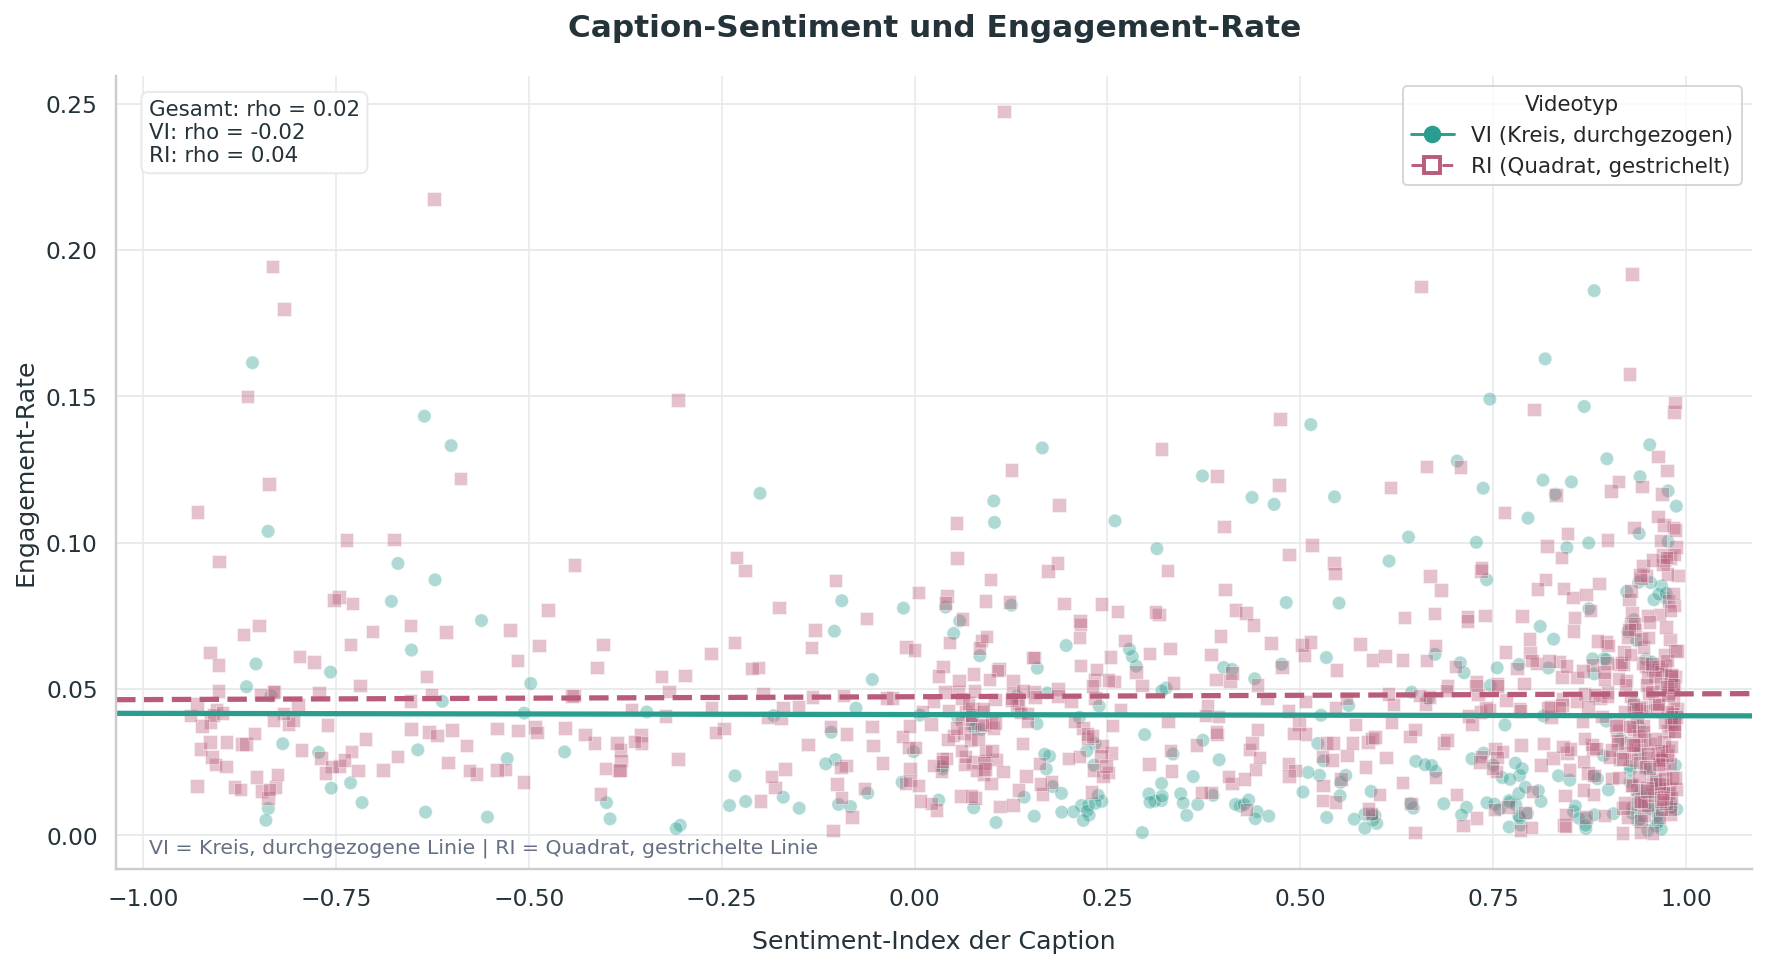

In [6]:
fig, ax3 = plt.subplots(figsize=(12.5, 6.8), constrained_layout=True)
sns.scatterplot(
    data=df,
    x="sentiment_index",
    y="video_engagement_rate",
    hue="Typ_plot",
    hue_order=["VI", "RI"],
    style="Typ_plot",
    style_order=["VI", "RI"],
    markers={"VI": "o", "RI": "s"},
    palette=PALETTE,
    alpha=0.38,
    s=48,
    ax=ax3,
)
for typ, color, linestyle in [("VI", COLOR_VI, "-"), ("RI", COLOR_RI, "--")]:
    subset = df[df["Typ_plot"] == typ]
    if len(subset) >= 2:
        sns.regplot(data=subset, x="sentiment_index", y="video_engagement_rate", scatter=False, ci=None, truncate=False, line_kws={"color": color, "linewidth": 2.7, "linestyle": linestyle}, ax=ax3)

ax3.set_title("Caption-Sentiment und Engagement-Rate", fontsize=16, fontweight="semibold", pad=20)
ax3.set_xlabel("Sentiment-Index der Caption", fontsize=13, labelpad=10)
ax3.set_ylabel("Engagement-Rate", fontsize=13)
ax3.tick_params(axis="both", labelsize=12)
stats_text = f"Gesamt: rho = {rho_all:.2f}\nVI: rho = {rho_ki:.2f}\nRI: rho = {rho_real:.2f}"
ax3.text(0.02, 0.97, stats_text, transform=ax3.transAxes, va="top", fontsize=11, color=COLOR_INK, bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": COLOR_GRID, "alpha": 0.96})
ax3.text(0.02, 0.02, "VI = Kreis, durchgezogene Linie | RI = Quadrat, gestrichelte Linie", transform=ax3.transAxes, fontsize=10.5, color=COLOR_MUTED)
engagement_legend = [
    Line2D([0], [0], color=COLOR_VI, marker="o", linestyle="-", markersize=8, label="VI (Kreis, durchgezogen)"),
    Line2D([0], [0], color=COLOR_RI, marker="s", markerfacecolor="white", markeredgewidth=2, linestyle="--", markersize=8, label="RI (Quadrat, gestrichelt)"),
]
ax3.legend(handles=engagement_legend, title="Videotyp", frameon=True, fontsize=11, title_fontsize=11, loc="upper right")
style_axis(ax3, x_grid=True)
plt.show()


In [7]:
ki_row = group_summary.loc[group_summary["Typ"]=="KI"].iloc[0]
real_row = group_summary.loc[group_summary["Typ"]=="Real"].iloc[0]
print("Deskriptive Kennwerte")
print(f"VI: n = {int(ki_row['n'])}, M = {ki_row['sentiment_index_M']:.3f}, SD = {ki_row['sentiment_index_SD']:.3f}, Md = {ki_row['sentiment_index_Md']:.3f}")
print(f"RI: n = {int(real_row['n'])}, M = {real_row['sentiment_index_M']:.3f}, SD = {real_row['sentiment_index_SD']:.3f}, Md = {real_row['sentiment_index_Md']:.3f}")
print(f"Gruppenunterschied: U = {u_stat:.2f}, p = {u_p:.4f}. Der Unterschied ist {p_text(u_p)}. Effektgröße: {d_interpretation(d_value)} (d = {d_value:.3f}).")
print(f"Label-Verteilung: chi2 = {chi2:.2f}, df = {chi2_df}, p = {chi2_p:.4f}. Die Verteilung ist {p_text(chi2_p)} unterschiedlich.")
print(f"Zusammenhang mit Engagement gesamt: rho = {rho_all:.3f}, p = {p_all:.4f}. Der Befund ist {p_text(p_all)} und entspricht {rho_interpretation(rho_all)}.")
print(f"Zusammenhang mit Engagement nur VI: rho = {rho_ki:.3f}, p = {p_ki:.4f}.")
print(f"Zusammenhang mit Engagement nur RI: rho = {rho_real:.3f}, p = {p_real:.4f}.")


Deskriptive Kennwerte
VI: n = 301, M = 0.433, SD = 0.504, Md = 0.552
RI: n = 728, M = 0.370, SD = 0.585, Md = 0.514
Gruppenunterschied: U = 111769.00, p = 0.6112. Der Unterschied ist nicht signifikant. Effektgröße: vernachlässigbar klein (d = 0.112).
Label-Verteilung: chi2 = 5.77, df = 2, p = 0.0560. Die Verteilung ist nicht signifikant unterschiedlich.
Zusammenhang mit Engagement gesamt: rho = 0.019, p = 0.5530. Der Befund ist nicht signifikant und entspricht praktisch kein Zusammenhang.
Zusammenhang mit Engagement nur VI: rho = -0.018, p = 0.7615.
Zusammenhang mit Engagement nur RI: rho = 0.044, p = 0.2347.
